<a href="https://colab.research.google.com/github/saladnga/CS4410-Homeworks/blob/main/CS4410_HW6_VuHoang_1677986.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Top-20 Word Frequency Bar Chart**

Required Installations & Downloads

In [11]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
import requests
from textblob import TextBlob
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import imageio.v3 as imageio

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Download Hamlet Text & Process Text with TextBlob

In [12]:
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text
blob = TextBlob(data)

Filter out Stop Words and Non-Alphabetic Words

In [37]:
stop_words = set(stopwords.words('english'))


In [38]:
word_counts = {}
for word, count in blob.word_counts.items():
  w = word.lower()
  if w.isalpha() and len(w) > 1 and w not in stop_words:
    word_counts[w] = count


Sort the items & Get the Top 20 words

In [39]:
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*sorted_words)

Plotting the Bar Chart

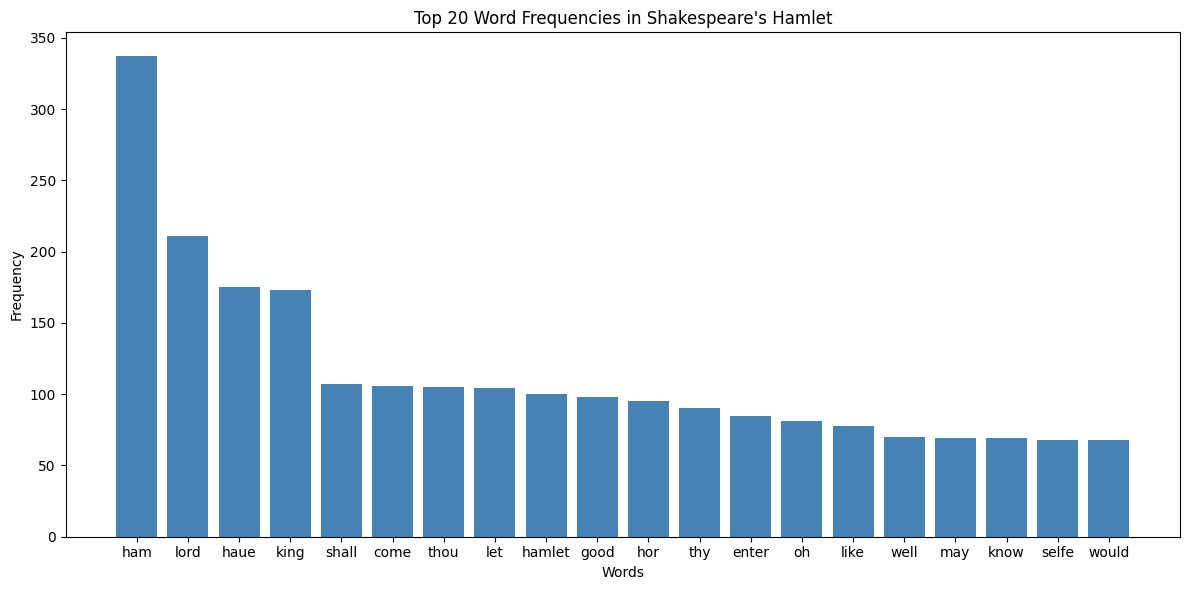

In [40]:
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='steelblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title("Top 20 Word Frequencies in Shakespeare's Hamlet")
plt.tight_layout()
plt.show()

**2. Word Cloud with Oval Mask**

Import the mask image provided in the assignment

In [29]:
image_file = 'https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png'
mask_image = imageio.imread(image_file)

Configure and generate the Word Cloud

In [35]:
wordcloud = WordCloud(
    width=800,
    height=400,
    colormap='prism',
    mask=mask_image,
    background_color='white'
)
wordcloud.generate(data)

Display the Word Cloud

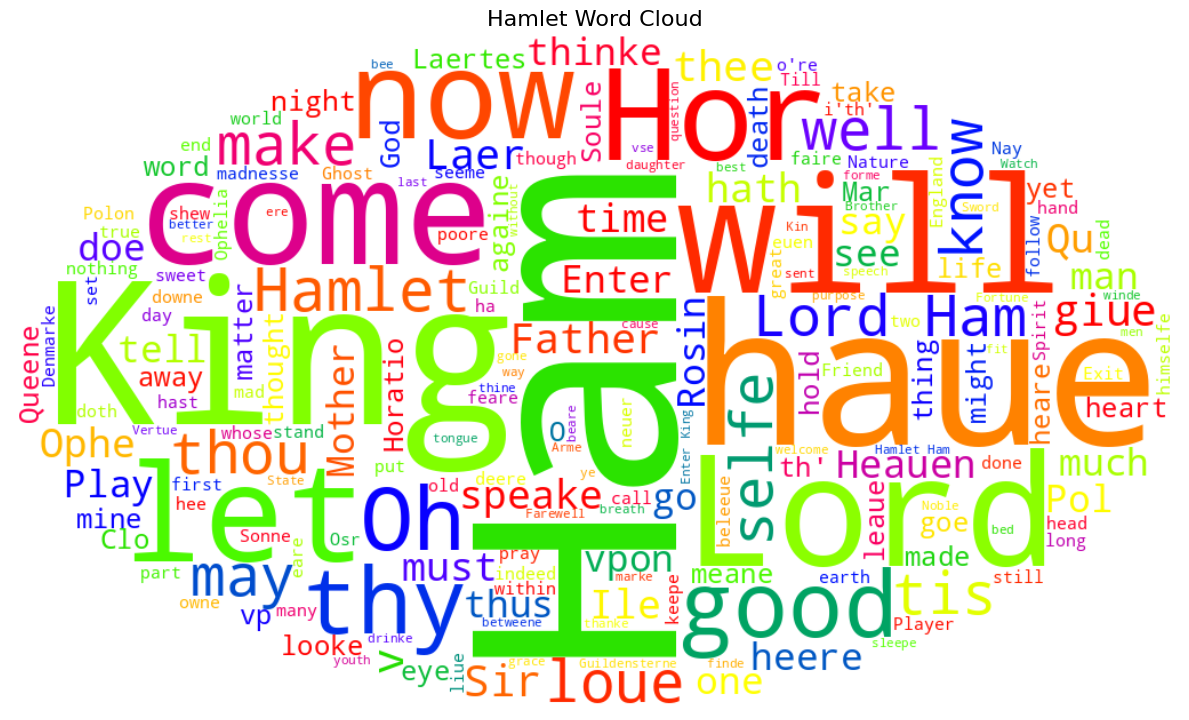

In [36]:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Hamlet Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()